### Initial Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
import bs4
from constants import player_columns_minus_name_v2, city_to_abbr_dict, team_abbr_to_id_dict, team_name_to_abbreviation, scope
from func import get_odds, append_data_to_sheet, find_team_name, find_injuriesv2, find_results, prep_training_data, scale_scores, calculate_team_power, get_current_data, predict_winner, predict_games, find_results
pd.options.mode.chained_assignment = None  # default='warn'

### Data Preparation

#### Helper Functions

In [2]:
from nba_api.stats.endpoints import TeamPlayerDashboard
from nba_api.stats.static.teams import find_team_name_by_id
from nba_api.stats.endpoints import LeagueDashTeamStats

import pandas as pd
import numpy as np
import re
from datetime import date
import gspread
from oauth2client.service_account import ServiceAccountCredentials
import joblib
import pickle as pk
import keras
import bs4


def get_odds(response):
    """
    Retrieves today's odds for NBA games 

    response (list) : list of today's games
    Returns:
    odds_dict (dict) : Dictionary of odds in {"team_abbr" : odds (int)} format
    """
    odds_dict = {}
    for game in response:
        first_bookmaker = game['bookmakers'][0] # first bookmaker in list of bookmakers (idc which bookmaker)
        for market in first_bookmaker['markets']:
            if market['key'] == 'h2h':
                outcomes = market['outcomes']
                for outcome in outcomes:
                    team_name = outcome['name']
                    team_abbr = team_name_to_abbreviation[team_name]
                    decimal_odds = outcome['price']
                    if decimal_odds >= 2:
                        american_odds = (decimal_odds - 1) * 100
                    else:
                        american_odds = (-100) / (decimal_odds - 1)
                    odds_dict[team_abbr] = round(american_odds)
    return odds_dict

def append_data_to_sheet(sheet_name: str, data: list):
    credentials = ServiceAccountCredentials.from_json_keyfile_name(
        "api_key.json", scope
    )
    gc = gspread.authorize(credentials)

    spreadsheet = gc.open("schrodinger")
    worksheet = spreadsheet.worksheet(sheet_name)
    worksheet.append_row(data)
    print("data append completed")


def find_team_name(tag: bs4.element.Tag) -> str:
    """
    Finds team name from a bs4 tag pulled previously

    Returns:
    team_name (str) : team name
    """
    pattern = r">(.*?)<\/a>" # regex pattern 
    team_name = str(tag.find_all(class_="TeamName")[0])
    team_name = re.search(pattern, team_name).group(1)
    team_name = team_name.split(">", 1)[-1]
    return team_name


def find_injuriesv2() -> dict:
    """
    CBSSports injury list (more accurate and up to date)

    Returns: 
    injuries (dict) : injured players around the league in {"team_abbr" : [injured players]} format
    """
    injuries = {}
    r = requests.get("https://www.cbssports.com/nba/injuries/")
    soup = BeautifulSoup(r.text, "html.parser")
    team_elements = soup.find_all(class_="TableBaseWrapper")
    for team_element in team_elements:
        team_name = find_team_name(team_element)
        team_abbr = city_to_abbr_dict[team_name]
        injuries[team_abbr] = []
        for report_element in team_element.find_all("tr", class_="TableBase-bodyTr"):
            player_name = report_element.find(
                "span", class_="CellPlayerName--long"
            ).text
            injuries[team_abbr].append(player_name)
    return injuries


def prep_training_data(data: pd.DataFrame, features):
    """
    Prepares data for model training by separating independent and dependent variables

    data (pd.DataFrame) : data prepared for training
    features (list) : specified features to filter

    Returns:
    X[features].values (list) : independent variables filtered by features in list format
    y (list) : dependent variables in list format
    """
    X = data.drop("HOME_TEAM_WIN", axis=1)
    y = pd.get_dummies(data, columns=["HOME_TEAM_WIN"], prefix="Result")[
        "Result_W"
    ].values # change W L to 0s and 1s
    return X[features].values, y


def scale_scores(scores: list) -> list:
    """
    Scales player importance scores on a team to add up to 100

    scores (list) : player importance scores

    Returns:
    scaled_values (list) : scaled player importance scores 
    """
    total = sum(scores)
    scaled_values = [value / total * 100 for value in scores]
    return scaled_values


def calculate_team_power(team_id: int, injuries: dict) -> float:
    """
    Calculates feature engineered "Team Power" which is a number between 1-100 that determines how full power a team is (taking into account injuries)

    team_id (int) : team id code from NBA API
    injuries (dict) : dictionary of injured players all throughout the league {"team_abbr" : [injured_players]}

    Returns:
    team_power (float) : team power score 
    """
    player_stats = TeamPlayerDashboard(
        team_id=team_id, per_mode_detailed="PerGame", season="2023-24"
    ).get_data_frames()[1]
    player_stats = player_stats.sort_values("MIN_RANK").iloc[0:8]
    player_stats["SCORE"] = player_stats[player_columns_minus_name_v2].sum(axis=1)
    scores = player_stats["SCORE"]
    player_stats["IMPORTANCE"] = scale_scores(scores)
    player_stats["IMPORTANCE"] = player_stats["IMPORTANCE"]
    team_power = 100
    team_abbr = find_team_name_by_id(team_id)["abbreviation"]
    if team_abbr in injuries:
        DNP_players_list = injuries[team_abbr]
    else:
        DNP_players_list = []
    print(team_abbr, DNP_players_list)
    for index, player in player_stats.iterrows():
        if player["PLAYER_NAME"] in DNP_players_list:
            team_power -= player["IMPORTANCE"]
    return team_power


def get_current_data() -> pd.DataFrame:
    """
    Retrieves current season data for real-time predicting purposes

    Returns:
    data (pd.DataFrame) : dataframe of all features we need in order to predict
    """
    base = LeagueDashTeamStats(
        season="2023-24",
        measure_type_detailed_defense="Base",
        per_mode_detailed="PerGame",
    ).get_data_frames()[0]
    advanced = LeagueDashTeamStats(
        season="2023-24",
        measure_type_detailed_defense="Advanced",
        per_mode_detailed="PerGame",
    ).get_data_frames()[0]
    scoring = LeagueDashTeamStats(
        season="2023-24",
        measure_type_detailed_defense="Scoring",
        per_mode_detailed="PerGame",
    ).get_data_frames()[0]
    opponent = LeagueDashTeamStats(
        season="2023-24",
        measure_type_detailed_defense="Opponent",
        per_mode_detailed="PerGame",
    ).get_data_frames()[0]
    defense = LeagueDashTeamStats(
        season="2023-24",
        measure_type_detailed_defense="Defense",
        per_mode_detailed="PerGame",
    ).get_data_frames()[0]
    last_10 = LeagueDashTeamStats(
        last_n_games=10,
        measure_type_detailed_defense="Base",
        per_mode_detailed="PerGame",
        season="2023-24",
    ).get_data_frames()[0]["W_PCT"]
    last_10.rename("LAST_10_W_PCT", inplace=True)
    return pd.concat([base, advanced, scoring, opponent, defense, last_10], axis=1)


def predict_winner(
    home_team_abbr: str,
    away_team_abbr: str,
    current_data: pd.DataFrame,
    features: list,
    pca_path : str,
    model_path : str,
    injuries: dict,
    sheet_name: str,
    game_id: str,
    scaler_path : str
):
    """
    Pipeline for real-time testing

    home_team_abbr (str) : home team abbreviation (CHI, BOS,...)
    home_team_abbr (str) : away team abbreviation (LAL, LAC,...)
    current_data (pd.DataFrame) : current season data for both teams used for training/predicting
    features (list) : list of features to use to predict
    pca_path (str) : file path for PCA 
    model_path (str) : Keras NN model file path
    injuries (dict) : Dictionary of injuries around the league {"team_abbr" : [injured_players]}
    sheet_name (str) : Personal use for Google Sheets
    game_id (str) : Game ID of the game to predict
    scaler_path (str) : file path for scaler 
    """
    home_team_id = team_abbr_to_id_dict[home_team_abbr]
    away_team_id = team_abbr_to_id_dict[away_team_abbr]

    current_data = current_data.loc[
        :, ~current_data.columns.duplicated()
    ]  # remove duplicate columns

    home_team_stats = current_data[
        current_data["TEAM_ID"] == home_team_id
    ]  # filter home team stats
    away_team_stats = current_data[
        current_data["TEAM_ID"] == away_team_id
    ]  # filter away team stats
    home_team_stats["TEAM_POWER"] = calculate_team_power(home_team_id, injuries)
    away_team_stats["TEAM_POWER"] = calculate_team_power(
        away_team_id, injuries
    )  # add team_power feature

    away_team_stats.columns = [col + "1" for col in away_team_stats.columns]
    home_team_stats_reset = home_team_stats.reset_index(drop=True)
    away_team_stats_reset = away_team_stats.reset_index(drop=True)

    test_data = pd.concat([home_team_stats_reset, away_team_stats_reset], axis=1)[
        features
    ].values

    scaler = joblib.load(scaler_path)
    test_data = scaler.transform(test_data)

    pca = pk.load(open(pca_path,'rb'))
    test_data = pca.transform(test_data)

    test_data = np.array(test_data).reshape(1, -1)

    model = keras.models.load_model(model_path)
    result = model.predict(test_data)

    home_team_win_percentage = result
    away_team_win_percentage = 1 - home_team_win_percentage

    data = [
            date.today().strftime("%m/%d/%Y"),
            home_team_abbr,
            away_team_abbr,
            home_team_abbr
            if home_team_win_percentage[0][0] > away_team_win_percentage[0][0]
            else away_team_abbr,
            float(home_team_win_percentage[0][0])
            if home_team_win_percentage[0][0] > away_team_win_percentage[0][0]
            else float(away_team_win_percentage[0][0]),
            game_id,
            None,
        ]
    
    append_data_to_sheet(sheet_name, data)

    print(home_team_abbr + ": " + str(home_team_win_percentage[0][0]))
    print(away_team_abbr + ": " + str(away_team_win_percentage[0][0]))

##### Combine years worth of data, drop NaNs, drop duplicate/unecessary columns

In [3]:
training_data = [
    pd.read_csv("./data/2021-22.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2021-22.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2022-23.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2022-23.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2020-21.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2020-21.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2019-20.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2019-20.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2018-19.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2018-19.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2017-18.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2017-18.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2016-17.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2016-17.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2015-16.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2015-16.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2014-15.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2014-15.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2013-14.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2013-14.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2010-11.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2010-11.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2009-10.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2009-10.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2008-09.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2008-09.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2007-08.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2007-08.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2006-07.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2006-07.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2005-06.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2005-06.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2004-05.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2004-05.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2003-04.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2003-04.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2002-03.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2002-03.csv", index_col=0).columns.duplicated()
    ],
    pd.read_csv("./data/2001-02.csv", index_col=0).loc[
        :, ~pd.read_csv("./data/2001-02.csv", index_col=0).columns.duplicated()
    ],
]

training_data = pd.concat(training_data)

for col in training_data.columns: # remove duplicate columns upon concatenating
    if ".1" in col:
        training_data.drop(columns=[col], inplace=True) 

training_data.drop(columns=["HOME_TEAM_NAME", "AWAY_TEAM_NAME", "DATE"], inplace=True) # drop uneccessary columns
training_data.dropna(inplace=True)

#### Drop Rank columns

In [4]:
# testing to reduce variable count/multicollinearity between rank and normal numerical stats
columns_to_drop = training_data.filter(like="RANK").columns.tolist()
columns_to_drop.append("W_PCT") # test with dropping win percentage  
training_data.drop(columns=columns_to_drop, inplace=True)

#### Drop non-rank columns (deprecated)

In [9]:
columns_to_keep = training_data.filter(like="RANK").columns.tolist()

columns_to_keep.append("HOME_TEAM_WIN")
columns_to_keep.append("LAST_10_W_PCT1")
columns_to_keep.append("LAST_10_W_PCT")
columns_to_keep.append("TEAM_POWER")
columns_to_keep.append("TEAM_POWER1")
training_data = training_data[columns_to_keep]

#### Prepare independent and dependent training data

In [5]:
from sklearn.preprocessing import StandardScaler

X = training_data.drop(columns = ["HOME_TEAM_WIN"])
features = X.columns
X = X.values
y = pd.get_dummies(training_data, columns=["HOME_TEAM_WIN"], prefix="Result")[
    "Result_W"
].values

#### Transform/Scale Data

In [26]:
from sklearn.preprocessing import MinMaxScaler

global_scaler = MinMaxScaler()
X = global_scaler.fit_transform(X)

### Model Training

In [56]:
from sklearn.model_selection import train_test_split

#### Main model (including all variables) (deprecated)

In [12]:
from keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import tensorflow as tf

NN_model = Sequential()
NN_model.add(
    Dense(
        units=80,
        activation="relu",
        input_dim=160,
    )
)
NN_model.add(Dropout(0.5))
NN_model.add(Dense(units=40, activation="relu"))
NN_model.add(Dropout(0.5))
NN_model.add(
    Dense(
        units=1,
        activation="sigmoid",
    )
)
NN_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.5, random_state=42
)

from sklearn.decomposition import PCA

pca = PCA(n_components=160)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
X_val = pca.transform(X_val)

history = NN_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
)

ValueError: n_components=160 must be between 0 and min(n_samples, n_features)=4 with svd_solver='full'

#### Model (without RANK variables)

##### Accuracy Model

In [45]:
# initialize model
from keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import tensorflow as tf

NN_model = Sequential()
NN_model.add(
    Dense(
        units=28,
        activation="relu",
        input_dim=55,
    )
)
NN_model.add(Dropout(0.45))
NN_model.add(Dense(units=14, activation="relu"))
NN_model.add(Dropout(0.45))
NN_model.add(
    Dense(
        units=1,
        activation="sigmoid",
    )
)
NN_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

Epoch 1/20
123/123 [==============================] - 0s 2ms/step - loss: 0.6735 - accuracy: 0.5807 - val_loss: 0.6369 - val_accuracy: 0.6455
Epoch 2/20
123/123 [==============================] - 0s 926us/step - loss: 0.6328 - accuracy: 0.6444 - val_loss: 0.5846 - val_accuracy: 0.7065
Epoch 3/20
123/123 [==============================] - 0s 968us/step - loss: 0.5941 - accuracy: 0.6875 - val_loss: 0.5543 - val_accuracy: 0.7181
Epoch 4/20
123/123 [==============================] - 0s 1ms/step - loss: 0.5763 - accuracy: 0.6970 - val_loss: 0.5444 - val_accuracy: 0.7241
Epoch 5/20
123/123 [==============================] - 0s 962us/step - loss: 0.5683 - accuracy: 0.7082 - val_loss: 0.5404 - val_accuracy: 0.7266
Epoch 6/20
123/123 [==============================] - 0s 937us/step - loss: 0.5620 - accuracy: 0.7124 - val_loss: 0.5400 - val_accuracy: 0.7260
Epoch 7/20
123/123 [==============================] - 0s 936us/step - loss: 0.5587 - accuracy: 0.7156 - val_loss: 0.5373 - val_accuracy: 0.7

In [ ]:
# prep train and test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.5, random_state=42
)
y_train_numerical = y_train.astype(int)
y_val_numerical = y_val.astype(int)

from sklearn.decomposition import PCA

# apply principal component analysis 
pca = PCA(n_components=0.99)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
X_val = pca.transform(X_val)

# train model
history = NN_model.fit(
    X_train,
    y_train_numerical,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val_numerical),
)

##### Precision Model

In [38]:
from keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import tensorflow as tf
from keras.metrics import Precision

precision_NN_model = Sequential()
precision_NN_model.add(
    Dense(
        units=29,
        activation="relu",
        input_dim=56,
    )
)
precision_NN_model.add(Dropout(0.45))
precision_NN_model.add(Dense(units=14, activation="relu"))
precision_NN_model.add(Dropout(0.45))
precision_NN_model.add(
    Dense(
        units=1,
        activation="sigmoid",
    )
)
precision_NN_model.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=[Precision()]
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.5, random_state=42
)
y_train_numerical = y_train.astype(int)
y_val_numerical = y_val.astype(int)
from sklearn.decomposition import PCA

pca = PCA(n_components=0.99)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
X_val = pca.transform(X_val)

y_train.shape
pca.n_components_
history = precision_NN_model.fit(
    X_train,
    y_train_numerical,
    epochs=25,
    batch_size=64,
    validation_data=(X_val, y_val_numerical),
)

Epoch 1/25
123/123 [==============================] - 1s 2ms/step - loss: 0.6737 - precision: 0.5972 - val_loss: 0.6466 - val_precision: 0.6063
Epoch 2/25
123/123 [==============================] - 0s 1ms/step - loss: 0.6322 - precision: 0.6295 - val_loss: 0.5806 - val_precision: 0.7072
Epoch 3/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5864 - precision: 0.7013 - val_loss: 0.5444 - val_precision: 0.7541
Epoch 4/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5680 - precision: 0.7304 - val_loss: 0.5374 - val_precision: 0.7683
Epoch 5/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5587 - precision: 0.7458 - val_loss: 0.5338 - val_precision: 0.7754
Epoch 6/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5531 - precision: 0.7503 - val_loss: 0.5301 - val_precision: 0.7650
Epoch 7/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5564 - precision: 0.7459 - val_loss: 0.5307 - val_precision:

##### Recall Model

In [40]:
from keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import tensorflow as tf
from keras.metrics import Recall

recall_NN_model = Sequential()
recall_NN_model.add(
    Dense(
        units=29,
        activation="relu",
        input_dim=56,
    )
)
recall_NN_model.add(Dropout(0.45))
recall_NN_model.add(Dense(units=14, activation="relu"))
recall_NN_model.add(Dropout(0.45))
recall_NN_model.add(
    Dense(
        units=1,
        activation="sigmoid",
    )
)
recall_NN_model.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=[Recall()]
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.5, random_state=42
)
y_train_numerical = y_train.astype(int)
y_val_numerical = y_val.astype(int)
from sklearn.decomposition import PCA

pca = PCA(n_components=0.99)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
X_val = pca.transform(X_val)

y_train.shape
pca.n_components_
history = recall_NN_model.fit(
    X_train,
    y_train_numerical,
    epochs=25,
    batch_size=64,
    validation_data=(X_val, y_val_numerical),
)

Epoch 1/25
123/123 [==============================] - 1s 2ms/step - loss: 0.6828 - recall: 0.7423 - val_loss: 0.6393 - val_recall: 0.9893
Epoch 2/25
123/123 [==============================] - 0s 1ms/step - loss: 0.6374 - recall: 0.8780 - val_loss: 0.5890 - val_recall: 0.9000
Epoch 3/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5928 - recall: 0.8210 - val_loss: 0.5487 - val_recall: 0.8203
Epoch 4/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5750 - recall: 0.7918 - val_loss: 0.5367 - val_recall: 0.8017
Epoch 5/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5714 - recall: 0.7828 - val_loss: 0.5346 - val_recall: 0.8041
Epoch 6/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5598 - recall: 0.8021 - val_loss: 0.5308 - val_recall: 0.8026
Epoch 7/25
123/123 [==============================] - 0s 1ms/step - loss: 0.5570 - recall: 0.7927 - val_loss: 0.5292 - val_recall: 0.7962
Epoch 8/25
123/123 [==============

In [46]:
import pickle as pk
pk.dump(pca, open("./models/v2/accuracy_pca.pkl", "wb"))

#### Model (with only RANK variables) (deprecated)

In [32]:
from keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import tensorflow as tf

NN_model = Sequential()
NN_model.add(
    Dense(
        units=75,
        activation="relu",
        input_dim=150,
    )
)
NN_model.add(Dropout(0.5))
NN_model.add(Dense(units=37, activation="relu"))
NN_model.add(Dropout(0.5))
NN_model.add(
    Dense(
        units=1,
        activation="sigmoid",
    )
)
NN_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [665]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.5, random_state=42
)

from sklearn.decomposition import PCA

pca = PCA(n_components=150)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
X_val = pca.transform(X_val)

history = NN_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
)

Epoch 1/10
33/33 [==============================] - 1s 9ms/step - loss: 0.6774 - accuracy: 0.5782 - val_loss: 0.6465 - val_accuracy: 0.6248
Epoch 2/10
33/33 [==============================] - 0s 4ms/step - loss: 0.6529 - accuracy: 0.6085 - val_loss: 0.6275 - val_accuracy: 0.6547
Epoch 3/10
33/33 [==============================] - 0s 4ms/step - loss: 0.6336 - accuracy: 0.6408 - val_loss: 0.6136 - val_accuracy: 0.6722
Epoch 4/10
33/33 [==============================] - 0s 4ms/step - loss: 0.6139 - accuracy: 0.6664 - val_loss: 0.6024 - val_accuracy: 0.6892
Epoch 5/10
33/33 [==============================] - 0s 4ms/step - loss: 0.6092 - accuracy: 0.6711 - val_loss: 0.5960 - val_accuracy: 0.6921
Epoch 6/10
33/33 [==============================] - 0s 4ms/step - loss: 0.6071 - accuracy: 0.6735 - val_loss: 0.5935 - val_accuracy: 0.6954
Epoch 7/10
33/33 [==============================] - 0s 4ms/step - loss: 0.5886 - accuracy: 0.6957 - val_loss: 0.5921 - val_accuracy: 0.6921
Epoch 8/10
33/33 [==

### Data Visualization

#### Visualize accuracy and errors:

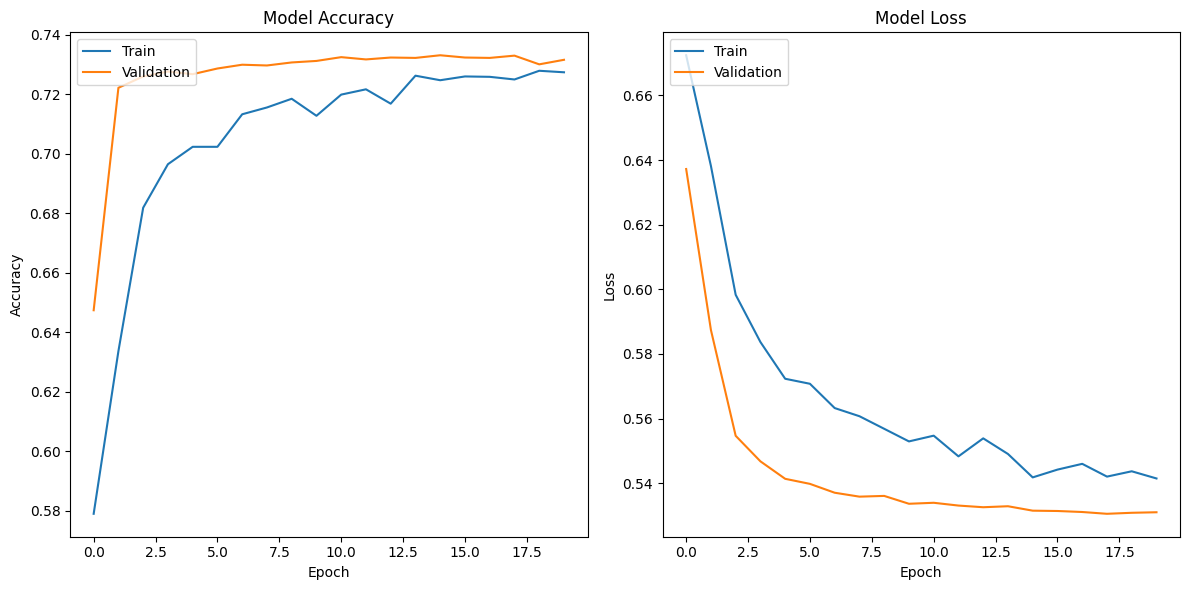

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"], loc="upper left")

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"], loc="upper left")

plt.tight_layout()
plt.show()

### Model Testing (test dataset)

#### Testing model with test data

In [43]:
results = NN_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {results[0]}")
print(f"Test Accuracy: {results[1]}")

Test Loss: 0.5190361142158508
Test Accuracy: 0.7318251132965088


### Live Testing (Retrieve and predict today's games)

In [55]:
from nba_api.live.nba.endpoints import ScoreBoard
import time
from sklearn.decomposition import PCA

features = ['FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'OFF_RATING', 'DEF_RATING', 'NET_RATING', 'AST_PCT', 'AST_TO', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT', 'TM_TOV_PCT', 'EFG_PCT', 'TS_PCT', 'E_PACE', 'PACE', 'PACE_PER40', 'POSS', 'PIE', 'PCT_FGA_2PT', 'PCT_FGA_3PT', 'PCT_PTS_2PT', 'PCT_PTS_2PT_MR', 'PCT_PTS_3PT', 'PCT_PTS_FB', 'PCT_PTS_FT', 'PCT_PTS_OFF_TOV', 'PCT_PTS_PAINT', 'PCT_AST_2PM', 'PCT_UAST_2PM', 'PCT_AST_3PM', 'PCT_UAST_3PM', 'PCT_AST_FGM', 'PCT_UAST_FGM', 'OPP_FGM', 'OPP_FGA', 'OPP_FG_PCT', 'OPP_FG3M', 'OPP_FG3A', 'OPP_FG3_PCT', 'OPP_FTM', 'OPP_FTA', 'OPP_FT_PCT', 'OPP_OREB', 'OPP_DREB', 'OPP_REB', 'OPP_AST', 'OPP_TOV', 'OPP_STL', 'OPP_BLK', 'OPP_BLKA', 'OPP_PF', 'OPP_PFD', 'OPP_PTS', 'OPP_PTS_OFF_TOV', 'OPP_PTS_2ND_CHANCE', 'OPP_PTS_FB', 'OPP_PTS_PAINT', 'LAST_10_W_PCT', 'TEAM_POWER', 'W_PCT1', 'FGM1', 'FGA1', 'FG_PCT1', 'FG3M1', 'FG3A1', 'FG3_PCT1', 'FTM1', 'FTA1', 'FT_PCT1', 'OREB1', 'DREB1', 'REB1', 'AST1', 'TOV1', 'STL1', 'BLK1', 'BLKA1', 'PF1', 'PFD1', 'PTS1', 'PLUS_MINUS1', 'OFF_RATING1', 'DEF_RATING1', 'NET_RATING1', 'AST_PCT1', 'AST_TO1', 'AST_RATIO1', 'OREB_PCT1', 'DREB_PCT1', 'REB_PCT1', 'TM_TOV_PCT1', 'EFG_PCT1', 'TS_PCT1', 'E_PACE1', 'PACE1', 'PACE_PER401', 'POSS1', 'PIE1', 'PCT_FGA_2PT1', 'PCT_FGA_3PT1', 'PCT_PTS_2PT1', 'PCT_PTS_2PT_MR1', 'PCT_PTS_3PT1', 'PCT_PTS_FB1', 'PCT_PTS_FT1', 'PCT_PTS_OFF_TOV1', 'PCT_PTS_PAINT1', 'PCT_AST_2PM1', 'PCT_UAST_2PM1', 'PCT_AST_3PM1', 'PCT_UAST_3PM1', 'PCT_AST_FGM1', 'PCT_UAST_FGM1', 'OPP_FGM1', 'OPP_FGA1', 'OPP_FG_PCT1', 'OPP_FG3M1', 'OPP_FG3A1', 'OPP_FG3_PCT1', 'OPP_FTM1', 'OPP_FTA1', 'OPP_FT_PCT1', 'OPP_OREB1', 'OPP_DREB1', 'OPP_REB1', 'OPP_AST1', 'OPP_TOV1', 'OPP_STL1', 'OPP_BLK1', 'OPP_BLKA1', 'OPP_PF1', 'OPP_PFD1', 'OPP_PTS1', 'OPP_PTS_OFF_TOV1', 'OPP_PTS_2ND_CHANCE1', 'OPP_PTS_FB1', 'OPP_PTS_PAINT1', 'LAST_10_W_PCT1', 'TEAM_POWER1']
# removed W_PCT 

scoreboard = ScoreBoard()
current_data = get_current_data()
injuries = find_injuriesv2()

# accuracy_modelv2 = keras.models.load_model("./models/v2/accuracy_model.keras")
# accuracy_modelv1 = keras.models.load_model("./models/accuray_model.keras")
# precision_model_v1 = keras.models.load_model("./models/precision_model.keras")
# recall_modelv1 = keras.models.load_model("./models/recall_model.keras")

for game_dict in scoreboard.get_dict()["scoreboard"]["games"]:
    game_id = game_dict["gameId"]
    home_team_abbr = game_dict["homeTeam"]["teamTricode"]
    away_team_abbr = game_dict["awayTeam"]["teamTricode"]
    predict_winner(
        home_team_abbr,
        away_team_abbr,
        current_data,
        features,
        "./models/v2/accuracy_pca.pkl",
        "./models/v2/accuracy_model.keras",
        injuries,
        "accuracyv2",
        game_id,
        "./models/v2/accuracy_scaler.save"
    )
    time.sleep(3)

# for game_dict in scoreboard.get_dict()["scoreboard"]["games"]:
#     pca = pk.load(open("./models/precision_pca.pkl",'rb'))
#     game_id = game_dict["gameId"]
#     home_team_abbr = game_dict["homeTeam"]["teamTricode"]
#     away_team_abbr = game_dict["awayTeam"]["teamTricode"]
#     predict_winner(
#         home_team_abbr,
#         away_team_abbr,
#         current_data,
#         features,
#         pca,
#         precision_NN_model,
#         injuries,
#         "precision",
#         game_id,
#     )
#     time.sleep(3)


# for game_dict in scoreboard.get_dict()["scoreboard"]["games"]:
#     pca = pk.load(open("./models/recall_pca.pkl",'rb'))
#     game_id = game_dict["gameId"]
#     home_team_abbr = game_dict["homeTeam"]["teamTricode"]
#     away_team_abbr = game_dict["awayTeam"]["teamTricode"]
#     predict_winner(
#         home_team_abbr,
#         away_team_abbr,
#         current_data,
#         features,
#         pca,
#         recall_NN_model,
#         injuries,
#         "recall",
#         game_id,
#     )
#     time.sleep(3)

CHA ['LaMelo Ball', 'Mark Williams']
ATL ['Mouhamed Gueye', 'AJ Griffin', 'Onyeka Okongwu', 'Wesley Matthews', 'Clint Capela']
1/1 [==============================] - 0s 27ms/step
data append completed
CHA: 0.30467308
ATL: 0.6953269
ORL ['Markelle Fultz', 'Jalen Suggs', 'Gary Harris']
NYK ['Isaiah Hartenstein', 'Donte DiVincenzo', 'Duane Washington Jr.', 'Bojan Bogdanovic', 'Julius Randle', 'OG Anunoby', 'Mitchell Robinson']
1/1 [==============================] - 0s 25ms/step
data append completed
ORL: 0.6967854
NYK: 0.3032146
PHI ["De'Anthony Melton", 'Tobias Harris', 'Nicolas Batum', 'Joel Embiid', 'Robert Covington']
MIA ['Terry Rozier', 'Jimmy Butler', 'Josh Richardson', 'Dru Smith']
1/1 [==============================] - 0s 25ms/step
data append completed
PHI: 0.3969171
MIA: 0.6030829
BOS ['Xavier Tillman', 'Jaden Springer', 'Jaylen Brown', 'Al Horford', 'Kristaps Porzingis']
BKN ['Ben Simmons', 'Dariq Whitehead']
1/1 [==============================] - 0s 26ms/step
data append comp

KeyboardInterrupt: 

### Code Work/Tests

#### Update truths

In [47]:
from nba_api.stats.endpoints import BoxScoreTraditionalV3

scope = [
    "https://spreadsheets.google.com/feeds",
    "https://www.googleapis.com/auth/drive",
]

credentials = ServiceAccountCredentials.from_json_keyfile_name(
    "api_key.json", scope
)
gc = gspread.authorize(credentials)
spreadsheet = gc.open("schrodinger")
worksheet = spreadsheet.worksheet("accuracy")
truths = []
for row_index, row_data in enumerate(worksheet.get_all_values()[1:], start=2):
    game_id = row_data[5]
    scoreboard = BoxScoreTraditionalV3(game_id)

    if row_data[6] == "":
        print("here")
        if (
            scoreboard.get_dict()["boxScoreTraditional"]["homeTeam"]["starters"][
                "minutes"
            ]
            == ""
        ):
            pass
        else:
            home_team_points = scoreboard.get_dict()["boxScoreTraditional"]["homeTeam"][
                "statistics"
            ]["points"]
            home_team_abbr = scoreboard.get_dict()["boxScoreTraditional"]["homeTeam"][
                "teamTricode"
            ]
            away_team_points = scoreboard.get_dict()["boxScoreTraditional"]["awayTeam"][
                "statistics"
            ]["points"]
            away_team_abbr = scoreboard.get_dict()["boxScoreTraditional"]["awayTeam"][
                "teamTricode"
            ]
            if home_team_points > away_team_points:
                differential = home_team_points - away_team_points
                worksheet.update_cell(row_index, 7, home_team_abbr)
                worksheet.update_cell(row_index, 8, differential)
                truths.append((row_index, home_team_abbr, differential))
                print("updated")
            else:
                differential = away_team_points - home_team_points
                worksheet.update_cell(row_index, 7, away_team_abbr)
                worksheet.update_cell(row_index, 8, differential)
                truths.append((row_index, away_team_abbr, differential))
                print("updated")
            time.sleep(3)

for sheet_name in ["precision", "recall"]:
    spreadsheet = gc.open("schrodinger")
    worksheet = spreadsheet.worksheet(sheet_name)
    for truth in truths:
        worksheet.update_cell(truth[0], 7, truth[1])
        worksheet.update_cell(truth[0], 8, truth[2])
        time.sleep(3)

here
updated
here
updated
here
updated
here
updated
here
updated
here
updated
here
updated


Single Game Testing

In [209]:
games = []
for game in scoreboard.get_dict()["scoreboard"]["games"]:
    print(game["gameTimeUTC"])

2024-01-23T00:00:00Z
2024-01-23T00:00:00Z
2024-01-23T00:00:00Z
2024-01-23T00:30:00Z
2024-01-23T01:00:00Z
2024-01-23T01:30:00Z
2024-01-23T02:00:00Z
2024-01-23T03:00:00Z


In [48]:
import os
from dotenv import load_dotenv
import requests
load_dotenv()
odds_api_key = os.environ.get("ODDS_API_KEY")
endpoint = f"https://api.the-odds-api.com/v4/sports/basketball_nba/odds/?regions=us&markets=h2h&apiKey={odds_api_key}"

In [20]:
odds_api_key

'04b462ab59ffc8e88dda3249076b6bb7'

In [49]:
r = requests.get(endpoint)

In [73]:
get_odds(r.json())

{'BKN': -105,
 'TOR': -115,
 'CLE': -345,
 'ORL': 270,
 'DET': 470,
 'IND': -667,
 'NYK': -105,
 'PHI': -115,
 'DAL': -130,
 'PHX': 110,
 'BOS': -286,
 'CHI': 230,
 'HOU': 225,
 'NOP': -278,
 'LAC': 114,
 'OKC': -135,
 'CHA': 350,
 'UTA': -455,
 'DEN': -1667,
 'WAS': 900,
 'GSW': -147,
 'LAL': 124,
 'SAC': -714,
 'SAS': 500}

In [17]:
endpoint = f"https://api.the-odds-api.com/v4/historical/sports/basketball_nba/odds?apiKey={odds_api_key}&regions=us&markets=h2h&date=2021-10-18T12:00:00Z"

In [18]:
r = requests.get(endpoint)

In [61]:
r.json()

[{'id': 'f9f3f99b5124a4ecf984003f0af23d2e',
  'sport_key': 'basketball_nba',
  'sport_title': 'NBA',
  'commence_time': '2024-02-23T00:10:00Z',
  'home_team': 'Toronto Raptors',
  'away_team': 'Brooklyn Nets',
  'bookmakers': [{'key': 'draftkings',
    'title': 'DraftKings',
    'last_update': '2024-02-17T05:35:01Z',
    'markets': [{'key': 'h2h',
      'last_update': '2024-02-17T05:35:01Z',
      'outcomes': [{'name': 'Brooklyn Nets', 'price': 1.95},
       {'name': 'Toronto Raptors', 'price': 1.87}]}]},
   {'key': 'mybookieag',
    'title': 'MyBookie.ag',
    'last_update': '2024-02-17T05:34:44Z',
    'markets': [{'key': 'h2h',
      'last_update': '2024-02-17T05:34:44Z',
      'outcomes': [{'name': 'Brooklyn Nets', 'price': 2.0},
       {'name': 'Toronto Raptors', 'price': 1.83}]}]},
   {'key': 'fanduel',
    'title': 'FanDuel',
    'last_update': '2024-02-17T05:33:07Z',
    'markets': [{'key': 'h2h',
      'last_update': '2024-02-17T05:33:07Z',
      'outcomes': [{'name': 'Brooklyn

In [35]:
response = [
    {
        "id": "bda33adca828c09dc3cac3a856aef176",
        "sport_key": "americanfootball_nfl",
        "commence_time": "2021-09-10T00:20:00Z",
        "home_team": "Tampa Bay Buccaneers",
        "away_team": "Dallas Cowboys",
        "bookmakers": [
            {
                "key": "unibet",
                "title": "Unibet",
                "last_update": "2021-06-10T13:33:18Z",
                "markets": [
                    {
                        "key": "h2h",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": 240
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -303
                            }
                        ]
                    },
                    {
                        "key": "spreads",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": -109,
                                "point": 6.5
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -111,
                                "point": -6.5
                            }
                        ]
                    }
                ]
            },
            {
                "key": "caesars",
                "title": "Caesars",
                "last_update": "2021-06-10T13:33:48Z",
                "markets": [
                    {
                        "key": "h2h",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": 240
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -278
                            }
                        ]
                    },
                    {
                        "key": "spreads",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": -110,
                                "point": 6.5
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -110,
                                "point": -6.5
                            }
                        ]
                    }
                ]
            },
            {
                "key": "sugarhouse",
                "title": "SugarHouse",
                "last_update": "2021-06-10T13:34:07Z",
                "markets": [
                    {
                        "key": "h2h",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": 240
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -305
                            }
                        ]
                    },
                    {
                        "key": "spreads",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": -109,
                                "point": 6.5
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -112,
                                "point": -6.5
                            }
                        ]
                    }
                ]
            },
            {
                "key": "draftkings",
                "title": "DraftKings",
                "last_update": "2021-06-10T13:33:26Z",
                "markets": [
                    {
                        "key": "h2h",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": 240
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -305
                            }
                        ]
                    },
                    {
                        "key": "spreads",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": -109,
                                "point": 6.5
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -112,
                                "point": -6.5
                            }
                        ]
                    }
                ]
            },
            {
                "key": "pointsbetus",
                "title": "PointsBet (US)",
                "last_update": "2021-06-10T13:36:20Z",
                "markets": [
                    {
                        "key": "h2h",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": 230
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -291
                            }
                        ]
                    },
                    {
                        "key": "spreads",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": -110,
                                "point": 6.5
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -110,
                                "point": -6.5
                            }
                        ]
                    }
                ]
            },
            {
                "key": "betonlineag",
                "title": "BetOnline.ag",
                "last_update": "2021-06-10T13:37:29Z",
                "markets": [
                    {
                        "key": "h2h",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": 240
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -286
                            }
                        ]
                    },
                    {
                        "key": "spreads",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": -105,
                                "point": 6
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -115,
                                "point": -6
                            }
                        ]
                    }
                ]
            },
            {
                "key": "betmgm",
                "title": "BetMGM",
                "last_update": "2021-06-10T13:32:45Z",
                "markets": [
                    {
                        "key": "h2h",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": 225
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -275
                            }
                        ]
                    },
                    {
                        "key": "spreads",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": -110,
                                "point": 6.5
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -110,
                                "point": -6.5
                            }
                        ]
                    }
                ]
            },
            {
                "key": "betrivers",
                "title": "BetRivers",
                "last_update": "2021-06-10T13:35:33Z",
                "markets": [
                    {
                        "key": "h2h",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": 240
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -305
                            }
                        ]
                    },
                    {
                        "key": "spreads",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": -109,
                                "point": 6.5
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -112,
                                "point": -6.5
                            }
                        ]
                    }
                ]
            },
            {
                "key": "fanduel",
                "title": "FanDuel",
                "last_update": "2021-06-10T13:33:23Z",
                "markets": [
                    {
                        "key": "h2h",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": 225
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -275
                            }
                        ]
                    },
                    {
                        "key": "spreads",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": -110,
                                "point": 6.5
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -110,
                                "point": -6.5
                            }
                        ]
                    }
                ]
            },
            {
                "key": "barstool",
                "title": "Barstool Sportsbook",
                "last_update": "2021-06-10T13:34:48Z",
                "markets": [
                    {
                        "key": "h2h",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": 240
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -305
                            }
                        ]
                    },
                    {
                        "key": "spreads",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": -109,
                                "point": 6.5
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -112,
                                "point": -6.5
                            }
                        ]
                    }
                ]
            },
            {
                "key": "bovada",
                "title": "Bovada",
                "last_update": "2021-06-10T13:35:51Z",
                "markets": [
                    {
                        "key": "h2h",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": 240
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -290
                            }
                        ]
                    },
                    {
                        "key": "spreads",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": -110,
                                "point": 6.5
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -110,
                                "point": -6.5
                            }
                        ]
                    }
                ]
            },
            {
                "key": "williamhill_us",
                "title": "William Hill (US)",
                "last_update": "2021-06-10T13:34:10Z",
                "markets": [
                    {
                        "key": "h2h",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": 240
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -280
                            }
                        ]
                    },
                    {
                        "key": "spreads",
                        "outcomes": [
                            {
                                "name": "Dallas Cowboys",
                                "price": -110,
                                "point": 6.5
                            },
                            {
                                "name": "Tampa Bay Buccaneers",
                                "price": -110,
                                "point": -6.5
                            }
                        ]
                    }
                ]
            }
        ]
    },
]

# create game odds dictionary with {"team_name" : odds}
# iterate through today's games, grab team_name, search in dictionary, retrieve odds, add to append row 
games_dict = {}
for game in response:
    home_team_abbr = team_name_to_abbreviation[game["home_team"]]
    away_team_abbr = team_name_to_abbreviation[game["away_team"]]
    games_dict[home_team_abbr]

In [ ]:
scope = [
    "https://spreadsheets.google.com/feeds",
    "https://www.googleapis.com/auth/drive",
]

credentials = ServiceAccountCredentials.from_json_keyfile_name(
    "api_key.json", scope
)
gc = gspread.authorize(credentials)
spreadsheet = gc.open("schrodinger")
worksheet = spreadsheet.worksheet("accuracyv2")
truths = []
for row_index, row_data in enumerate(worksheet.get_all_values()[1:], start=2):
    game_id = row_data[5]
    scoreboard = BoxScoreTraditionalV3(game_id)

    if row_data[6] == "":
        print("here")
        if (
            scoreboard.get_dict()["boxScoreTraditional"]["homeTeam"]["starters"][
                "minutes"
            ]
            == ""
        ):
            pass
        else:
            home_team_points = scoreboard.get_dict()["boxScoreTraditional"]["homeTeam"][
                "statistics"
            ]["points"]
            home_team_abbr = scoreboard.get_dict()["boxScoreTraditional"]["homeTeam"][
                "teamTricode"
            ]
            away_team_points = scoreboard.get_dict()["boxScoreTraditional"]["awayTeam"][
                "statistics"
            ]["points"]
            away_team_abbr = scoreboard.get_dict()["boxScoreTraditional"]["awayTeam"][
                "teamTricode"
            ]
            if home_team_points > away_team_points:
                differential = home_team_points - away_team_points
                worksheet.update_cell(row_index, 7, home_team_abbr)
                worksheet.update_cell(row_index, 8, differential)
                truths.append((row_index, home_team_abbr, differential))
                print("updated")
            else:
                differential = away_team_points - home_team_points
                worksheet.update_cell(row_index, 7, away_team_abbr)
                worksheet.update_cell(row_index, 8, differential)
                truths.append((row_index, away_team_abbr, differential))
                print("updated")
            time.sleep(3)

In [1]:
from nba_api.live.nba.endpoints.scoreboard import ScoreBoard
from datetime import datetime, timedelta
scoreboard = ScoreBoard()

In [32]:


for game in scoreboard.get_dict()['scoreboard']['games']:
    first_game_datetime = datetime.strptime(game['gameEt'], "%Y-%m-%dT%H:%M:%SZ")
    first_game_datetime = first_game_datetime - timedelta(hours = 1)
    current_datetime = datetime.now()
    difference = first_game_datetime - current_datetime
    if difference <= timedelta(hours=1):
        # run predictions, mark true so it doesnt predict again
        pass
    else:
        break

-1 day, 18:41:44.777481
-1 day, 19:11:44.777433
-1 day, 19:41:44.777423


In [2]:
from nba_api.stats.endpoints import TeamPlayerDashboard
from nba_api.stats.static.teams import find_team_name_by_id
from nba_api.stats.endpoints import LeagueDashTeamStats
from nba_api.stats.endpoints import BoxScoreTraditionalV3
from nba_api.live.nba.endpoints import ScoreBoard

import pandas as pd

def get_current_data() -> pd.DataFrame:
    """
    Retrieves current season data for real-time predicting purposes

    Returns:
    data (pd.DataFrame) : dataframe of all features we need in order to predict
    """
    base = LeagueDashTeamStats(
        season="2023-24",
        measure_type_detailed_defense="Base",
        per_mode_detailed="PerGame",
    ).get_data_frames()[0]
    advanced = LeagueDashTeamStats(
        season="2023-24",
        measure_type_detailed_defense="Advanced",
        per_mode_detailed="PerGame",
    ).get_data_frames()[0]
    scoring = LeagueDashTeamStats(
        season="2023-24",
        measure_type_detailed_defense="Scoring",
        per_mode_detailed="PerGame",
    ).get_data_frames()[0]
    opponent = LeagueDashTeamStats(
        season="2023-24",
        measure_type_detailed_defense="Opponent",
        per_mode_detailed="PerGame",
    ).get_data_frames()[0]
    defense = LeagueDashTeamStats(
        season="2023-24",
        measure_type_detailed_defense="Defense",
        per_mode_detailed="PerGame",
    ).get_data_frames()[0]
    last_10 = LeagueDashTeamStats(
        last_n_games=10,
        measure_type_detailed_defense="Base",
        per_mode_detailed="PerGame",
        season="2023-24",
    ).get_data_frames()[0]["W_PCT"]
    last_10.rename("LAST_10_W_PCT", inplace=True)
    return pd.concat([base, advanced, scoring, opponent, defense, last_10], axis=1)

In [3]:
current_data = get_current_data()

In [5]:
current_data.iloc[0]['LAST_10']

TEAM_ID                       1610612737
TEAM_NAME                  Atlanta Hawks
GP                                    55
W                                     24
L                                     31
                               ...      
OPP_PTS_OFF_TOV_RANK                  14
OPP_PTS_2ND_CHANCE_RANK               26
OPP_PTS_FB_RANK                       28
OPP_PTS_PAINT_RANK                    28
LAST_10_W_PCT                        0.6
Name: 0, Length: 227, dtype: object